# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$ 

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice. 
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

All data are provided in `ProblemD_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train_labeled` | (200, 256) | $N=200$ **labeled** initial fields, sampled at 256 spatial sensors |
| `u_train_labeled` | (200, 200, 256) | Corresponding FDM-computed velocity fields on a $200\times256$ spatio-temporal grid |
| `a_train_unlabeled` | (1800, 256) | $N=1800$ **unlabeled** initial fields (no paired solution available) |
| `a_test` | (200, 256) | Test initial conditions (**do not use for training**) |
| `u_test` | (200, 200, 256) | Ground truth velocity fields for test instances (**do not use for training**) |
| `x_mesh` | (256, 1) | Spatial coordinates of the 256 grid points |
| `t_mesh` | (200, 1) | Temporal coordinates of the 200 time steps |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>
t_mesh: torch.Size([200, 1]) x_mesh: torch.Size([256, 1])
a_train_labeled: torch.Size([200, 256]) u_train_labeled: torch.Size([200, 200, 256])
a_train_unlabeled: torch.Size([1800, 256])
a_test: torch.Size([200, 256]) u_test: torch.Size([200, 200, 256])


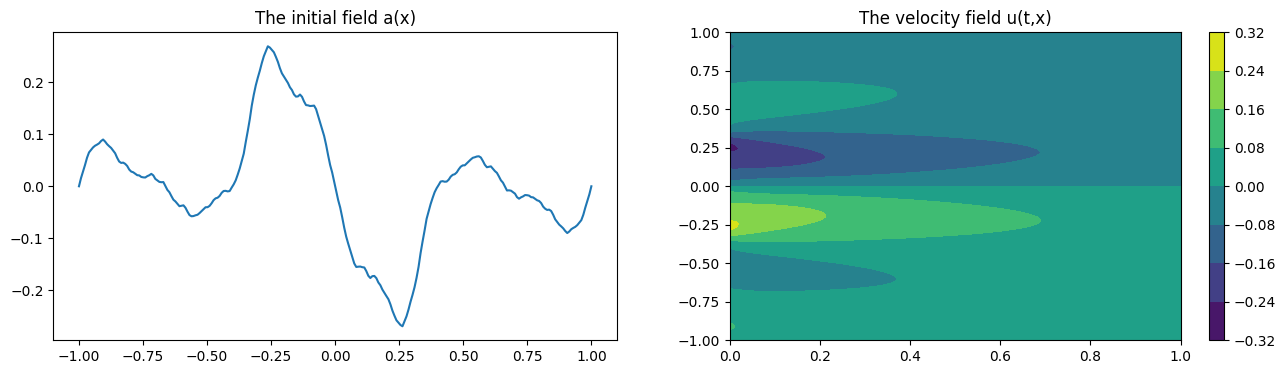

In [2]:
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('ProblemD_dataset.h5', 'r') as file:
    print(file.keys())
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)
    a_train_unlabeled = torch.tensor(np.array(file['a_train_unlabeled']), dtype=dtype)
    #
    X, T = np.meshgrid(x_mesh, t_mesh)
#
print('t_mesh:', t_mesh.shape, 'x_mesh:', x_mesh.shape)
print('a_train_labeled:', a_train_labeled.shape, 'u_train_labeled:', u_train_labeled.shape)
print('a_train_unlabeled:', a_train_unlabeled.shape)
print('a_test:', a_test.shape, 'u_test:', u_test.shape)
#################################
inx = 0
fig, axes = plt.subplots(1,2, figsize=(16,4))
#
cntr = axes[0].plot(x_mesh, a_train_labeled[0])
axes[0].set_title('The initial field a(x)')
#
cntr = axes[1].contourf(T, X, u_train_labeled[inx])
axes[1].set_title('The velocity field u(t,x)')
plt.colorbar(cntr)
#
plt.show()

Using device: cuda
nu =  0.03183098861837907

Keys: <KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>

The shape of t_mesh: torch.Size([200, 1])
The shape of x_mesh: torch.Size([256, 1])
The shape of a_train_labeled: torch.Size([200, 256])
The shape of u_train_labeled: torch.Size([200, 200, 256])
The shape of a_train_unlabeled: torch.Size([1800, 256])
The shape of a_test: torch.Size([200, 256])
The shape of u_test: torch.Size([200, 200, 256])

The shape of ax_train_labeled: torch.Size([200, 200, 256, 3])
The shape of u_train_labeled: torch.Size([200, 200, 256, 1])
The shape of ax_train_unlabeled: torch.Size([1800, 200, 256, 3])
The shape of ax_test: torch.Size([200, 200, 256, 3])
The shape of u_test: torch.Size([200, 200, 256, 1])

dt = 0.005025125574320555
dx = 0.00784313678741455


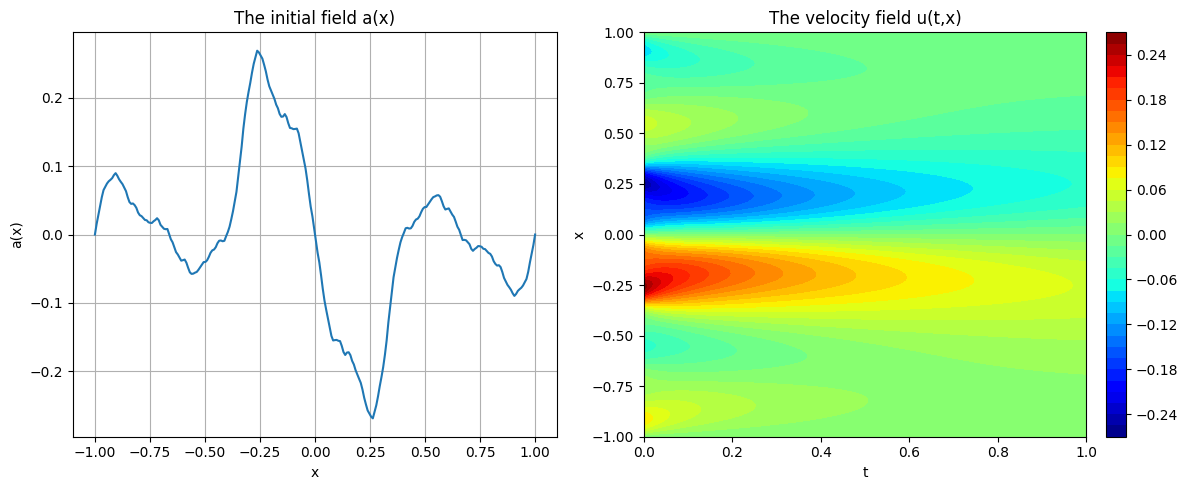

3,552,593 trainable parameters.


  5%|▌         | 50/1000 [14:16<4:32:27, 17.21s/it]

Epoch:50, loss:7.821248e-04, pde:8.504852e-01, data:7.821248e-04, test_error:2.768605e-01, best_error:2.755812e-01, lambda_r:0.000e+00, lr:1.000e-03


 10%|█         | 100/1000 [28:31<4:17:54, 17.19s/it]

Epoch:100, loss:7.578730e-04, pde:8.387545e-01, data:7.578730e-04, test_error:2.736472e-01, best_error:2.736472e-01, lambda_r:0.000e+00, lr:1.000e-03


...

 95%|█████████▌| 950/1000 [4:39:11<15:03, 18.06s/it]

Epoch:950, loss:9.122182e-02, pde:9.117995e-03, data:4.186648e-05, test_error:5.675588e-02, best_error:2.615522e-02, lambda_r:1.000e+01, lr:1.250e-04


100%|██████████| 1000/1000 [4:54:12<00:00, 17.65s/it]

Epoch:1000, loss:9.126498e-02, pde:9.123053e-03, data:3.445197e-05, test_error:3.660527e-02, best_error:2.615522e-02, lambda_r:1.000e+01, lr:6.250e-05
Training time: 17652.266602039337
Best test L2 relative error: 0.0261552182585001
Model saved to: ProblemD_PINO_best_model.pth


The shape of u_test_pred: torch.Size([200, 200, 256, 1])
Final average L2 relative error: 0.026155218482017517


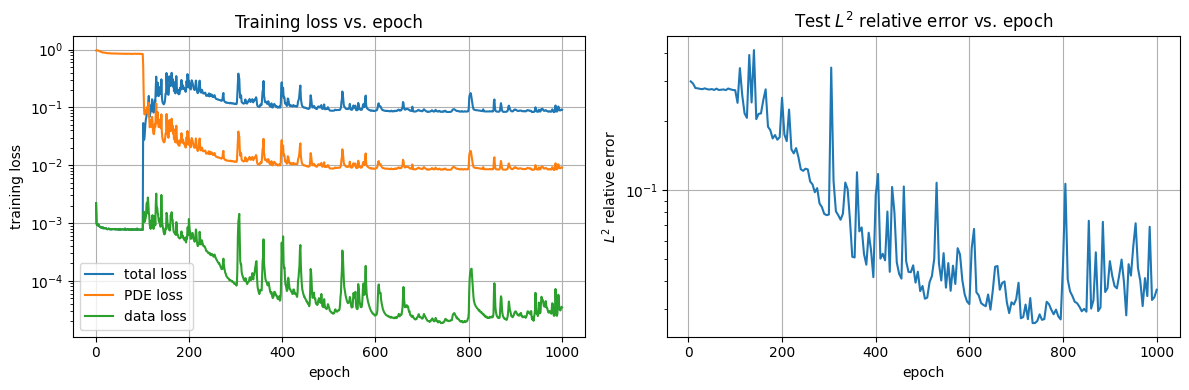

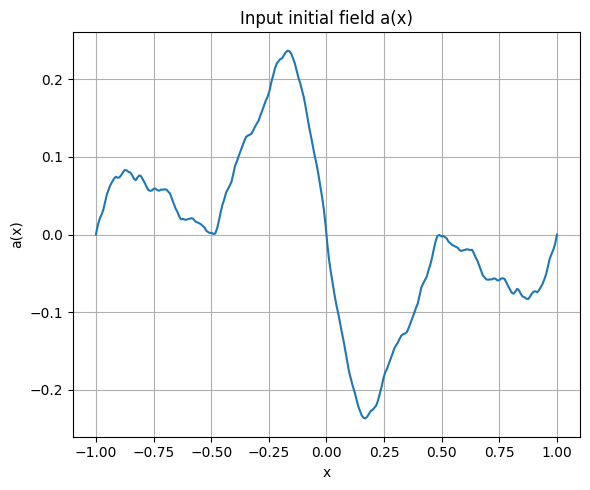

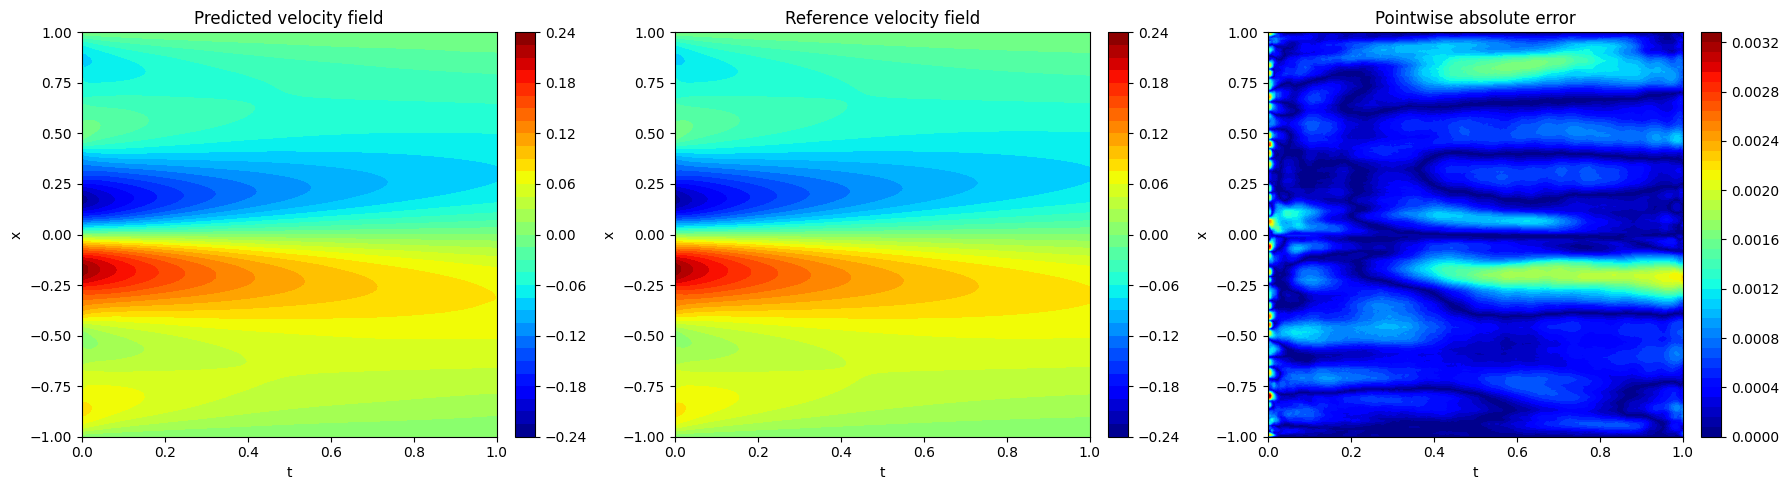

In [1]:
#############################################################
# Problem D: Learning the solution operator a(x) -> u(t,x)
# Method: Physics-Informed Neural Operator (PINO)
#############################################################


#############################################################
# Step 0: Import packages and global settings
#############################################################

import os
import time
import h5py
import itertools
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm import trange
from torch.utils.data import Dataset, DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

np.random.seed(1234)
torch.manual_seed(1234)

if device.type == "cuda":
    torch.cuda.manual_seed_all(1234)
    torch.backends.cudnn.benchmark = True

print("Using device:", device)

# Viscosity coefficient in Burgers equation:
#     u_t + u u_x - nu u_xx = 0
nu = 0.1/np.pi
print("nu = ", nu)

#############################################################
# Step 1: Load dataset
#############################################################

with h5py.File("ProblemD_dataset.h5", "r") as data:
    print("\nKeys:", data.keys())

    t_mesh = torch.tensor(np.array(data["t_mesh"]), dtype=dtype)
    x_mesh = torch.tensor(np.array(data["x_mesh"]), dtype=dtype)
    a_train_labeled = torch.tensor(np.array(data["a_train_labeled"]), dtype=dtype)
    u_train_labeled = torch.tensor(np.array(data["u_train_labeled"]), dtype=dtype)
    a_train_unlabeled = torch.tensor(np.array(data["a_train_unlabeled"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test = torch.tensor(np.array(data["u_test"]), dtype=dtype)

print("\nThe shape of t_mesh:", t_mesh.shape)
print("The shape of x_mesh:", x_mesh.shape)
print("The shape of a_train_labeled:", a_train_labeled.shape)
print("The shape of u_train_labeled:", u_train_labeled.shape)
print("The shape of a_train_unlabeled:", a_train_unlabeled.shape)
print("The shape of a_test:", a_test.shape)
print("The shape of u_test:", u_test.shape)


#############################################################
# Step 2: Prepare FNO input ax = [a(x), t, x]
#############################################################

def prepare_ax(a, t_mesh, x_mesh):
    """
    Input:
        a:      torch tensor, shape (N, Nx)
        t_mesh: torch tensor, shape (Nt, 1)
        x_mesh: torch tensor, shape (Nx, 1)
    Return:
        ax: torch tensor, shape (N, Nt, Nx, 3)
    Function:
        Build FNO/PINO input:
            ax[...,0] = a(x), repeated along time direction
            ax[...,1] = t
            ax[...,2] = x
    """

    ndata = a.shape[0]
    nx = a.shape[1]
    nt = t_mesh.shape[0]

    # a: (N, Nx) -> (N, 1, Nx) -> (N, Nt, Nx)
    a_rep = a.reshape(ndata, 1, nx).repeat(1, nt, 1)

    # T, X: both shape (Nt, Nx)
    T, X = torch.meshgrid(t_mesh.reshape(-1), x_mesh.reshape(-1), indexing="ij")

    T = T.reshape(1, nt, nx).repeat(ndata, 1, 1)
    X = X.reshape(1, nt, nx).repeat(ndata, 1, 1)

    ax = torch.stack([a_rep, T, X], dim=-1)

    return ax


ax_train_labeled = prepare_ax(a_train_labeled, t_mesh, x_mesh)
ax_train_unlabeled = prepare_ax(a_train_unlabeled, t_mesh, x_mesh)
ax_test = prepare_ax(a_test, t_mesh, x_mesh)

u_train_labeled = u_train_labeled.reshape(u_train_labeled.shape[0], u_train_labeled.shape[1], u_train_labeled.shape[2], 1)
u_test = u_test.reshape(u_test.shape[0], u_test.shape[1], u_test.shape[2], 1)

print("\nThe shape of ax_train_labeled:", ax_train_labeled.shape)
print("The shape of u_train_labeled:", u_train_labeled.shape)
print("The shape of ax_train_unlabeled:", ax_train_unlabeled.shape)
print("The shape of ax_test:", ax_test.shape)
print("The shape of u_test:", u_test.shape)


# Grid spacing
dt = (t_mesh[1, 0] - t_mesh[0, 0]).item()
dx = (x_mesh[1, 0] - x_mesh[0, 0]).item()

print("\ndt =", dt)
print("dx =", dx)


#############################################################
# Step 3: Visualize one labeled training sample
#############################################################

sample_id = 0

a_show = a_train_labeled[sample_id]
u_show = u_train_labeled[sample_id, ..., 0]

T_plot, X_plot = torch.meshgrid(t_mesh.reshape(-1), x_mesh.reshape(-1), indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Initial field a(x)
axes[0].plot(x_mesh.reshape(-1), a_show)
axes[0].set_title("The initial field a(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("a(x)")
axes[0].grid(True)

# Velocity field u(t,x)
cntr = axes[1].contourf(T_plot, X_plot, u_show, levels=40, cmap="jet")
fig.colorbar(cntr, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("The velocity field u(t,x)")
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")

plt.tight_layout()
plt.show()


#############################################################
# Step 4: Define Spectral Convolution Layer
#############################################################

class SpectralConv2d(nn.Module):

    def __init__(self, in_size, out_size, modes1, modes2, dtype=None):
        super(SpectralConv2d, self).__init__()
        """
        2D Fourier layer:
            FFT -> truncate low Fourier modes -> linear transform -> inverse FFT
        Input:
            x: shape (batch_size, in_size, nt, nx)
        Return:
            x: shape (batch_size, out_size, nt, nx)
        """

        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1.0 / (in_size * out_size)

        if dtype is None or dtype == torch.float32:
            ctype = torch.complex64
        elif dtype == torch.float64:
            ctype = torch.complex128
        else:
            raise TypeError("Unsupported dtype.")

        self.weight1 = nn.Parameter(self.scale * torch.randn(in_size, out_size, modes1, modes2, dtype=ctype))
        self.weight2 = nn.Parameter(self.scale * torch.randn(in_size, out_size, modes1, modes2, dtype=ctype))

    def compl_mul_2d(self, input, weights):
        """
        Complex multiplication.
        Input:
            input:   shape (batch_size, in_size, modes1, modes2)
            weights: shape (in_size, out_size, modes1, modes2)
        Return:
            output: shape (batch_size, out_size, modes1, modes2)
        """

        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        """
        Input:
            x: shape (batch_size, in_size, nt, nx)
        Return:
            x: shape (batch_size, out_size, nt, nx)
        """

        batch_size = x.shape[0]

        # Fourier transform
        x_ft = torch.fft.rfft2(x)

        # Allocate Fourier coefficients
        out_ft = torch.zeros(batch_size, self.out_size, x.size(-2), x.size(-1) // 2 + 1, device=x.device, dtype=torch.cfloat)

        # Positive low-frequency modes
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul_2d(x_ft[:, :, :self.modes1, :self.modes2], self.weight1)

        # Negative low-frequency modes in first direction
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul_2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weight2)

        # Inverse Fourier transform
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x


#############################################################
# Step 5: Define FNO2d model
#############################################################

class FNO2d(nn.Module):

    def __init__(self, in_size: int, out_size: int, modes1: int, modes2: int, hidden_list: list, dtype=None, hard_bc=True):
        super(FNO2d, self).__init__()
        """
        FNO2d for learning:
            a(x) -> u(t,x)
        Input:
            ax: shape (batch_size, Nt, Nx, 3)
        Output:
            u: shape (batch_size, Nt, Nx, 1)
        """

        self.hidden_list = hidden_list
        self.hard_bc = hard_bc

        self.activation = nn.GELU()

        # Input lifting layer
        self.fc_in = nn.Linear(in_size, hidden_list[0], dtype=dtype)

        # Fourier layers and pointwise linear layers
        conv_net = []
        w_net = []

        self.hidden_in = hidden_list[0]

        for hidden in hidden_list[1:]:
            conv_net.append(SpectralConv2d(self.hidden_in, hidden, modes1, modes2, dtype=dtype))
            w_net.append(nn.Conv1d(self.hidden_in, hidden, kernel_size=1, dtype=dtype))
            self.hidden_in = hidden

        self.spectral_conv = nn.Sequential(*conv_net)
        self.weight_conv = nn.Sequential(*w_net)

        # Output projection layer
        self.fc_out0 = nn.Linear(self.hidden_in, 128, dtype=dtype)
        self.fc_out1 = nn.Linear(128, out_size, dtype=dtype)

    def forward(self, ax):
        """
        Input:
            ax: shape (batch_size, Nt, Nx, 3)
        Return:
            u: shape (batch_size, Nt, Nx, 1)
        """

        batch_size = ax.shape[0]
        nt = ax.shape[1]
        nx = ax.shape[2]

        # Save grid for hard boundary condition
        x_grid = ax[..., 1:2]
        y_grid = ax[..., 2:3]

        # Input lifting:
        # (batch, nt, nx, in_size) -> (batch, nt, nx, hidden)
        ax = self.fc_in(ax)

        # Move channel to second dimension:
        # (batch, nt, nx, hidden) -> (batch, hidden, nt, nx)
        ax = ax.permute(0, 3, 1, 2)

        hidden_last = self.hidden_list[0]

        # Fourier layers
        for conv, weight, hidden_size in zip(self.spectral_conv, self.weight_conv, self.hidden_list[1:]):
            ax1 = conv(ax)
            ax2 = weight(ax.reshape(batch_size, hidden_last, -1)).reshape(batch_size, hidden_size, nt, nx)
            ax = self.activation(ax1 + ax2)
            hidden_last = hidden_size

        # Move channel back:
        # (batch, hidden, nt, nx) -> (batch, nt, nx, hidden)
        ax = ax.permute(0, 2, 3, 1)

        ax = self.fc_out0(ax)
        ax = self.activation(ax)

        u = self.fc_out1(ax)

        return u


#############################################################
# Step 6: Define normalizer
#############################################################

class UnitGaussianNormalizer(object):

    def __init__(self, ax, eps=1e-8):
        """
        Apply normalization to the first channel of the last axis.
        Input:
            ax: torch tensor, shape (N, nt, nx, c)
        For ax = [a, t, x]:
            normalize only a, keep t,x unchanged.
        For u:
            normalize u.
        """

        self.mean = torch.mean(ax[..., 0:1], dim=0)
        self.std = torch.std(ax[..., 0:1], dim=0)
        self.eps = eps

    def encode(self, ax):
        """
        Input:
            ax: torch tensor, shape (N, nt, nx, c)
        Return:
            ax_norm: same shape as ax
        """
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([(ax_list[0] - self.mean) / (self.std + self.eps), ax_list[1]], dim=-1)

        return ax

    def decode(self, ax):
        """
        Input:
            ax_norm: torch tensor, shape (N, nt, nx, c)
        Return:
            ax: same shape as ax_norm
        """
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([ax_list[0] * (self.std + self.eps) + self.mean, ax_list[1]], dim=-1)

        return ax


#############################################################
# Step 7: Create model and normalizers
#############################################################

# For input normalizer, use both labeled and unlabeled initial fields
ax_train_all = torch.cat([ax_train_labeled, ax_train_unlabeled], dim=0)

ax_train_all_gpu = ax_train_all.to(device)
u_train_labeled_gpu = u_train_labeled.to(device)

normalizer_ax = UnitGaussianNormalizer(ax_train_all_gpu)
normalizer_u = UnitGaussianNormalizer(u_train_labeled_gpu)

# empty cuda memory
del ax_train_all_gpu
del u_train_labeled_gpu
if device.type == "cuda":
    torch.cuda.empty_cache()

# Model hyperparameters
modes1 = 16
modes2 = 16
hidden_list = [48, 48, 48, 48]

model_u = FNO2d(in_size=ax_train_labeled.shape[-1], out_size=u_train_labeled.shape[-1], modes1=modes1, modes2=modes2, hidden_list=hidden_list, dtype=dtype, hard_bc=True).to(device)

total_trainable_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} trainable parameters.")


#############################################################
# Step 8: Define dataset and dataloader
#############################################################

class MyDataset(Dataset):

    def __init__(self, ax, u=None):
        """
        Input:
            ax: shape (N, Nt, Nx, 3)
            u:  shape (N, Nt, Nx, 1), optional
        """
        self.ax = ax
        self.u = u

    def __getitem__(self, index):
        if self.u is None:
            return self.ax[index]
        else:
            return self.ax[index], self.u[index]

    def __len__(self):
        return self.ax.shape[0]


batch_size_labeled = 4
batch_size_unlabeled = 36

labeled_loader = DataLoader(MyDataset(ax_train_labeled, u_train_labeled), batch_size=batch_size_labeled, shuffle=True, num_workers=0, pin_memory=True if device.type == "cuda" else False)
unlabeled_loader = DataLoader(MyDataset(ax_train_unlabeled), batch_size=batch_size_unlabeled, shuffle=True, num_workers=0, pin_memory=True if device.type == "cuda" else False)


#############################################################
# Step 9: Define loss class
#############################################################

class LossClass(object):

    def __init__(self, u_model, lambda_r=1.0, lambda_d=1.0, nu=0.01, dx=1.0, dt=1.0):
        """
        Args:
            u_model   : FNO2d
            lambda_r  : weight for PDE residual loss
            lambda_d  : weight for supervised data loss
            lambda_ic : weight for initial condition loss
            nu        : viscosity coefficient in Burgers equation
            dx        : spatial grid size
            dt        : temporal grid size
        """
        self.device = device

        self.u_model = u_model

        self.lambda_r = lambda_r
        self.lambda_d = lambda_d

        self.nu = nu
        self.dx = dx
        self.dt = dt

    def _predict(self, ax_batch):
        """
        Forward pass with normalization and hard IC/BC mollifier.

        Input:
            ax_batch: shape (B, Nt, Nx, 3)
        Return:
            u_pred: shape (B, Nt, Nx), physical velocity field

        Hard constraint:
            u_theta(t,x) = (1-t) a(x) + t(1-x^2) N_theta(t,x)
        Therefore:
            u_theta(0,x) = a(x)
            u_theta(t,-1) = u_theta(t,1) = 0
        """

        # Original physical inputs
        a_grid = ax_batch[..., 0:1]      # (B, Nt, Nx, 1)
        t_grid = ax_batch[..., 1:2]      # (B, Nt, Nx, 1)
        x_grid = ax_batch[..., 2:3]      # (B, Nt, Nx, 1)

        # Neural operator raw output
        ax_norm = normalizer_ax.encode(ax_batch)
        raw_norm = self.u_model(ax_norm)

        # Decode raw output to physical scale
        raw = normalizer_u.decode(raw_norm)

        # Hard IC + hard BC
        u_pred = (1.0 - t_grid) * a_grid + t_grid * (1.0 - x_grid ** 2) * raw

        return u_pred[..., 0]

    def loss_pde_from_u(self, u):
        """
        Burgers PDE residual loss:
            R[u] = u_t + u u_x - nu u_xx
        Only ax_batch is needed. No labeled u is required.

        Input:
            u: shape (B, Nt, Nx)
        Return:
            loss_pde: scalar
        """

        # Time derivative: -> (B, Nt-1, Nx-2)
        # u_t(t_n, x_i) = (u(t_{n+1}, x_i) - u(t_n, x_i)) / dt
        u_t = (u[:, 1:, 1:-1] - u[:, :-1, 1:-1]) / self.dt

        # Spatial derivative: -> (B, Nt-1, Nx-2)
        u_x = (u[:, :-1, 2:] - u[:, :-1, :-2]) / (2.0 * self.dx)
        u_xx = (u[:, :-1, 2:] - 2.0 * u[:, :-1, 1:-1] + u[:, :-1, :-2]) / (self.dx ** 2)

        u_center = u[:, :-1, 1:-1]

        residual = u_t + u_center * u_x - self.nu * u_xx

        loss = torch.mean(residual ** 2)

        return loss

    def loss_data_from_u(self, u, u_batch):
        """
        Supervised data loss on labeled pairs.

        Input:
            u       : shape (B, Nt, Nx)
            u_batch : shape (B, Nt, Nx, 1)
        Return:
            loss_data: scalar
        """

        u_true = u_batch[..., 0]      # shape (B, Nt, Nx)
        
        loss = torch.mean((u_true - u) ** 2)

        return loss

    def loss_total(self, ax_labeled_batch, u_labeled_batch, ax_unlabeled_batch=None):
        """
        Total PINO loss:
            L = lambda_r * L_pde + lambda_d * L_data + lambda_ic * L_ic

        L_data is only computed on labeled data.
        L_pde and L_ic are computed on labeled and unlabeled data.
        """

        u_labeled_pred = self._predict(ax_labeled_batch)
        labeled_batch_size = ax_labeled_batch.shape[0]

        loss_pde_labeled = self.loss_pde_from_u(u_labeled_pred)
        # keep L_data, do not scale with labeled + unlabeled
        loss_data = self.loss_data_from_u(u_labeled_pred, u_labeled_batch)

        if ax_unlabeled_batch is not None:

            u_unlabeled_pred = self._predict(ax_unlabeled_batch)
            unlabeled_batch_size = ax_unlabeled_batch.shape[0]

            loss_pde_unlabeled = self.loss_pde_from_u(u_unlabeled_pred)

            loss_pde = (labeled_batch_size * loss_pde_labeled + unlabeled_batch_size * loss_pde_unlabeled) / (labeled_batch_size + unlabeled_batch_size)

        else:
            loss_pde = loss_pde_labeled

        loss = (self.lambda_r * loss_pde + self.lambda_d * loss_data)

        return loss, loss_pde, loss_data

    def get_error(self, ax, u, batch_size_eval=20):
        """
        Compute mean relative L2 error on labeled pairs.

        Input:
            ax: shape (N, Nt, Nx, 3)
            u:  shape (N, Nt, Nx, 1)

        Return:
            mean relative L2 error
        """

        self.u_model.eval()

        ndata = ax.shape[0]
        error_sum = 0.0

        with torch.no_grad():

            for i in range(0, ndata, batch_size_eval):

                ax_batch = ax[i:i + batch_size_eval].to(self.device)
                u_batch = u[i:i + batch_size_eval].to(self.device)

                u_pred = self._predict(ax_batch)
                u_true = u_batch[..., 0]

                error_batch = (
                    torch.norm(
                        (u_true - u_pred).reshape(u_pred.shape[0], -1),
                        2,
                        dim=1
                    )
                    /
                    torch.norm(
                        u_true.reshape(u_pred.shape[0], -1),
                        2,
                        dim=1
                    )
                )

                error_sum += torch.sum(error_batch).item()

        self.u_model.train()

        return error_sum / ndata

    def predict(self, ax, batch_size_eval=20):
        """
        Predict u for a whole dataset.

        Input:
            ax: shape (N, Nt, Nx, 3)

        Return:
            u_pred: shape (N, Nt, Nx, 1), CPU tensor
        """

        self.u_model.eval()

        pred_list = []

        with torch.no_grad():

            for i in range(0, ax.shape[0], batch_size_eval):

                ax_batch = ax[i:i + batch_size_eval].to(self.device)

                u_pred = self._predict(ax_batch)

                pred_list.append(
                    u_pred[..., None].detach().cpu()
                )

        self.u_model.train()

        return torch.cat(pred_list, dim=0)


#############################################################
# Step 10: Training setup
#############################################################

epochs = 1000
warmup_epochs = 100
ramp_epochs = 100
eval_interval = 5

lr = 1e-3
weight_decay = 1e-4

optimizer = torch.optim.Adam(params=model_u.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=250, gamma=0.5)

lossClass = LossClass(model_u, lambda_r=0.0, lambda_d=1.0, nu=nu, dx=dx, dt=dt)

loss_list = []
loss_pde_list = []
loss_data_list = []
error_list = []
eval_epochs = []

best_error = float("inf")
best_state = None


#############################################################
# Step 11: Training process
#############################################################

t0 = time.time()

for epoch in trange(epochs):
    """
    epoch 0-99:      lambda_r = 0
    epoch 100-199:   lambda_r from 0.0 to 10.0
    epoch 200-999:   lambda_r = 10.0
    """
    # warm-up train
    if epoch < warmup_epochs:
        lossClass.lambda_r = 0.0
    # ramp-up PINO residual
    elif epoch < warmup_epochs + ramp_epochs:
        ratio = (epoch - warmup_epochs) / ramp_epochs
        lossClass.lambda_r = ratio * 10.0
    # full PINO
    else:
        lossClass.lambda_r = 10.0

    model_u.train()

    epoch_loss = 0.0
    epoch_pde = 0.0
    epoch_data = 0.0

    labeled_iter = itertools.cycle(labeled_loader)

    for ax_unlabeled_batch in unlabeled_loader:

        ax_labeled_batch, u_labeled_batch = next(labeled_iter)

        ax_labeled_batch = ax_labeled_batch.to(device, non_blocking=True)
        u_labeled_batch = u_labeled_batch.to(device, non_blocking=True)
        ax_unlabeled_batch = ax_unlabeled_batch.to(device, non_blocking=True)

        loss_train, loss_pde, loss_data = lossClass.loss_total(ax_labeled_batch, u_labeled_batch, ax_unlabeled_batch)

        optimizer.zero_grad(set_to_none=True)

        loss_train.backward()

        torch.nn.utils.clip_grad_norm_(model_u.parameters(), max_norm=5.0)

        optimizer.step()

        epoch_loss += loss_train.item()
        epoch_pde += loss_pde.item()
        epoch_data += loss_data.item()

    scheduler.step()

    epoch_loss = epoch_loss / len(unlabeled_loader)
    epoch_pde = epoch_pde / len(unlabeled_loader)
    epoch_data = epoch_data / len(unlabeled_loader)

    loss_list.append(epoch_loss)
    loss_pde_list.append(epoch_pde)
    loss_data_list.append(epoch_data)

    if (epoch + 1) % eval_interval == 0:
        error = lossClass.get_error(ax_test, u_test, batch_size_eval=10)
        error_list.append(error)
        eval_epochs.append(epoch + 1)

        if error < best_error:
            best_error = error
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model_u.state_dict().items()
            }

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch:{epoch+1}, "
            f"loss:{epoch_loss:.6e}, "
            f"pde:{epoch_pde:.6e}, "
            f"data:{epoch_data:.6e}, "
            f"test_error:{error:.6e}, "
            f"best_error:{best_error:.6e}, "
            f"lambda_r:{lossClass.lambda_r:.3e}, "
            f"lr:{optimizer.param_groups[0]['lr']:.3e}"
        )

print("Training time:", time.time() - t0)


#############################################################
# Step 12: Load best model
#############################################################

if best_state is not None:

    model_u.load_state_dict(
        {
            key: value.to(device)
            for key, value in best_state.items()
        })

print("Best test L2 relative error:", best_error)


#############################################################
# Step 12.5: Save trained model
#############################################################

save_path = "ProblemD_PINO_best_model.pth"

torch.save(
    {
        "model_state_dict": model_u.state_dict(),
        "best_error": best_error,
        "modes1": modes1,
        "modes2": modes2,
        "hidden_list": hidden_list,
        "nu": nu,
        "dx": dx,
        "dt": dt,
        "normalizer_ax_mean": normalizer_ax.mean.detach().cpu(),
        "normalizer_ax_std": normalizer_ax.std.detach().cpu(),
        "normalizer_u_mean": normalizer_u.mean.detach().cpu(),
        "normalizer_u_std": normalizer_u.std.detach().cpu(),
        "loss_list": loss_list,
        "loss_pde_list": loss_pde_list,
        "loss_data_list": loss_data_list,
        "error_list": error_list,
        "eval_epochs": eval_epochs,
    },
    save_path
)

print("Model saved to:", save_path)


#############################################################
# Step 13: Final prediction and final L2 relative error
#############################################################

u_test_pred = lossClass.predict(ax_test, batch_size_eval=10)
u_test_cpu = u_test.detach().cpu()

l2_error_each = (
    torch.norm(
        u_test_pred.reshape(u_test_pred.shape[0], -1)
        -
        u_test_cpu.reshape(u_test_cpu.shape[0], -1),
        p=2,
        dim=1
    )
    /
    torch.norm(
        u_test_cpu.reshape(u_test_cpu.shape[0], -1),
        p=2,
        dim=1
    )
)

final_error = torch.mean(l2_error_each)

print("The shape of u_test_pred:", u_test_pred.shape)
print("Final average L2 relative error:", final_error.item())


#############################################################
# Step 14: Plot loss vs epoch and error vs epoch
#############################################################

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(1, len(loss_list) + 1), loss_list, label="total loss")
axes[0].semilogy(np.arange(1, len(loss_pde_list) + 1), loss_pde_list, label="PDE loss")
axes[0].semilogy(np.arange(1, len(loss_data_list) + 1), loss_data_list, label="data loss")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss vs. epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(eval_epochs, error_list)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel(r"$L^2$ relative error")
axes[1].set_title(r"Test $L^2$ relative error vs. epoch")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 15: Visualize prediction, truth, and pointwise error
#############################################################

sample_id = 0

a_show = a_test[sample_id].detach().cpu()

u_true = u_test_cpu[sample_id, ..., 0]
u_pred = u_test_pred[sample_id, ..., 0]

abs_error = torch.abs(u_true - u_pred)

T_plot_cpu = T_plot.detach().cpu()
X_plot_cpu = X_plot.detach().cpu()


# Plot input initial condition a(x)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x_mesh.reshape(-1).detach().cpu(), a_show)

ax.set_title("Input initial field a(x)")
ax.set_xlabel("x")
ax.set_ylabel("a(x)")
ax.grid(True)

plt.tight_layout()
plt.show()


# Plot predicted u, reference u, and pointwise absolute error
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted u
cntr0 = axes[0].contourf(T_plot_cpu, X_plot_cpu, u_pred, levels=40, cmap="jet")
fig.colorbar(cntr0, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title("Predicted velocity field")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")


# Reference u
cntr1 = axes[1].contourf(T_plot_cpu, X_plot_cpu, u_true, levels=40, cmap="jet")
fig.colorbar(cntr1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("Reference velocity field")
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")


# Absolute error
cntr2 = axes[2].contourf(T_plot_cpu, X_plot_cpu, abs_error, levels=40, cmap="jet")
fig.colorbar(cntr2, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title("Pointwise absolute error")
axes[2].set_xlabel("t")
axes[2].set_ylabel("x")

plt.tight_layout()
plt.show()

In [2]:
#############################################################
# Step 12.5: Save trained model
#############################################################

save_path = "ProblemD_PINO_best_model.pth"

torch.save(
    {
        "model_state_dict": model_u.state_dict(),
        "best_error": best_error,
        "modes1": modes1,
        "modes2": modes2,
        "hidden_list": hidden_list,
        "nu": nu,
        "dx": dx,
        "dt": dt,
        "normalizer_ax_mean": normalizer_ax.mean.detach().cpu(),
        "normalizer_ax_std": normalizer_ax.std.detach().cpu(),
        "normalizer_u_mean": normalizer_u.mean.detach().cpu(),
        "normalizer_u_std": normalizer_u.std.detach().cpu(),
        "loss_list": loss_list,
        "loss_pde_list": loss_pde_list,
        "loss_data_list": loss_data_list,
        "error_list": error_list,
        "eval_epochs": eval_epochs,
    },
    save_path
)

print("Model saved to:", save_path)

Model saved to: ProblemD_PINO_best_model.pth
